# 02 — Data Quality & Validation
**CRISP-DM Phase 2b: Data Quality Assessment**

---

### Purpose

Before any modelling, we must prove the data is **fit for purpose**. This notebook performs eight systematic checks across all four data sources (customer records, cease events, call centre, usage telemetry) and produces a machine-populated **pass / fail gate** at the end.

| # | Check | What It Catches |
|---|-------|-----------------|
| 1 | Schema validation | Wrong types, unexpected values, constraint violations |
| 2 | Completeness & null rates | Missing data that could bias features |
| 3 | Duplicate profiling | Inflated counts, duplicate-driven label corruption |
| 4 | Join / referential integrity | Orphan records, modelling coverage gaps |
| 5 | Temporal coverage | Date-range gaps, anomalous future dates |
| 6 | Outliers & cardinality | Negative tenure, zero speeds, high-cardinality categoricals |
| 7 | Leakage risk verification | Post-churn data contaminating feature snapshots |
| 8 | Quality gate summary | Automated pass / fail dashboard |

---

In [14]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandera as pa

from churn.data.loader import ingest_raw_tables, get_connection
from churn.data.validator import (
    cease_schema, customer_info_schema, calls_schema, usage_schema,
    validate_cease, validate_customer_info, validate_calls, validate_usage,
)
from churn.config import cfg

# ── Executive visual theme ────────────────────────────────────────────────────
%matplotlib inline
ACCENT   = '#1565C0'
PASS_CLR = '#388E3C'
FAIL_CLR = '#D32F2F'
WARN_CLR = '#F57C00'
NEUTRAL  = '#546E7A'
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120})

# ── Load data (skip ingestion if tables already exist) ────────────────────────
con = get_connection()

existing_tables = {r[0] for r in con.execute("SHOW TABLES").fetchall()}
required_tables = {'cease', 'customer_info', 'calls', 'usage'}

if required_tables.issubset(existing_tables):
    print('Tables already present in DuckDB — skipping re-ingestion.')
else:
    missing = required_tables - existing_tables
    print(f'Missing tables {missing} — ingesting raw files …')
    ingest_raw_tables(con)

# Track pass/fail results for the quality gate
quality_gate: dict[str, tuple[str, str]] = {}   # {check_name: (status, note)}
print('Data loaded — quality checks begin.')

Tables already present in DuckDB — skipping re-ingestion.
Data loaded — quality checks begin.


## 1. Schema Validation

Validate all **four** data sources against Pandera schemas. Large tables are sampled (50K rows) to keep validation fast while maintaining statistical coverage.

In [2]:
# Load small tables fully; sample large ones for validation
cease = con.execute('SELECT * FROM cease').fetchdf()
customer_info_sample = con.execute('SELECT * FROM customer_info USING SAMPLE 50000').fetchdf()
calls_sample = con.execute('SELECT * FROM calls USING SAMPLE 50000').fetchdf()
usage_sample = con.execute('SELECT * FROM usage USING SAMPLE 50000').fetchdf()

schema_results = []
schema_failures = {}          # table → list of check names that failed
for name, df, schema in [
    ('cease',                      cease,               cease_schema),
    ('customer_info (50K sample)', customer_info_sample, customer_info_schema),
    ('calls (50K sample)',         calls_sample,         calls_schema),
    ('usage (50K sample)',         usage_sample,         usage_schema),
]:
    try:
        schema.validate(df, lazy=True)
        schema_results.append((name, '✓ PASS', ''))
        print(f'✓ {name} — passed schema validation ({len(df):,} rows)')
    except pa.errors.SchemaErrors as e:
        n_fail = len(e.failure_cases)
        schema_results.append((name, '✗ FAIL', f'{n_fail} violation(s)'))
        schema_failures[name] = e.failure_cases['check'].tolist()
        print(f'✗ {name} — FAILED ({n_fail} violation(s)):')
        display(e.failure_cases.head(20))

# ── Quantify cease date-ordering violations for context ──
cease_tmp = cease.copy()
cease_tmp['_completed'] = pd.to_datetime(cease_tmp['cease_completed_date'], errors='coerce')
cease_tmp['_placed']    = pd.to_datetime(cease_tmp['cease_placed_date'], errors='coerce')
bad_dates   = ((cease_tmp['_completed'].notna()) & (cease_tmp['_placed'].notna())
               & (cease_tmp['_completed'] < cease_tmp['_placed'])).sum()
placed_null = ((cease_tmp['_completed'].notna()) & (cease_tmp['_placed'].isna())).sum()
date_issues = bad_dates + placed_null
if date_issues > 0:
    parts = []
    if bad_dates:   parts.append(f'{bad_dates:,} with completed < placed')
    if placed_null: parts.append(f'{placed_null:,} with placed_date NULL but completed filled')
    print(f'\n⚠ cease date-ordering: {date_issues:,} issue rows '
          f'({date_issues/len(cease):.2%}): {"; ".join(parts)}')
    print(f'  → Pipeline uses cease_placed_date for labelling; completion date only')
    print(f'    used for processing-window analysis (filtered out). Low impact.')

# ── Gate logic ──
# Known & mitigated: sole failure is the cease date-ordering check
KNOWN_CEASE_CHECK = 'cease_completed_date must be >= cease_placed_date'
all_passed  = all(s[1].startswith('✓') for s in schema_results)
only_known  = (
    set(schema_failures.keys()) == {'cease'}
    and all(c == KNOWN_CEASE_CHECK for c in schema_failures.get('cease', []))
)
quality_gate['Schema validation'] = (
    'PASS' if all_passed else ('WARN' if only_known else 'FAIL'),
    '; '.join(f'{s[0]}: {s[1]} {s[2]}' for s in schema_results)
    + (f' [{date_issues:,} date-order issues — mitigated]' if date_issues > 0 else '')
)

✗ cease — FAILED (1 violation(s)):


,column,failure_case,index,schema_context,check,check_number
0,None,False,None,DataFrameSchema,cease_completed_date must be >= cease_placed_date,0


✓ customer_info (50K sample) — passed schema validation (50,000 rows)
✓ calls (50K sample) — passed schema validation (50,000 rows)
✓ usage (50K sample) — passed schema validation (50,000 rows)


## 2. Completeness — Null Rates & Missing Data

Assess the per-column null rate across all four tables. Columns with >30% nulls may require imputation or exclusion. Visualised as a heatmap for executive readability.

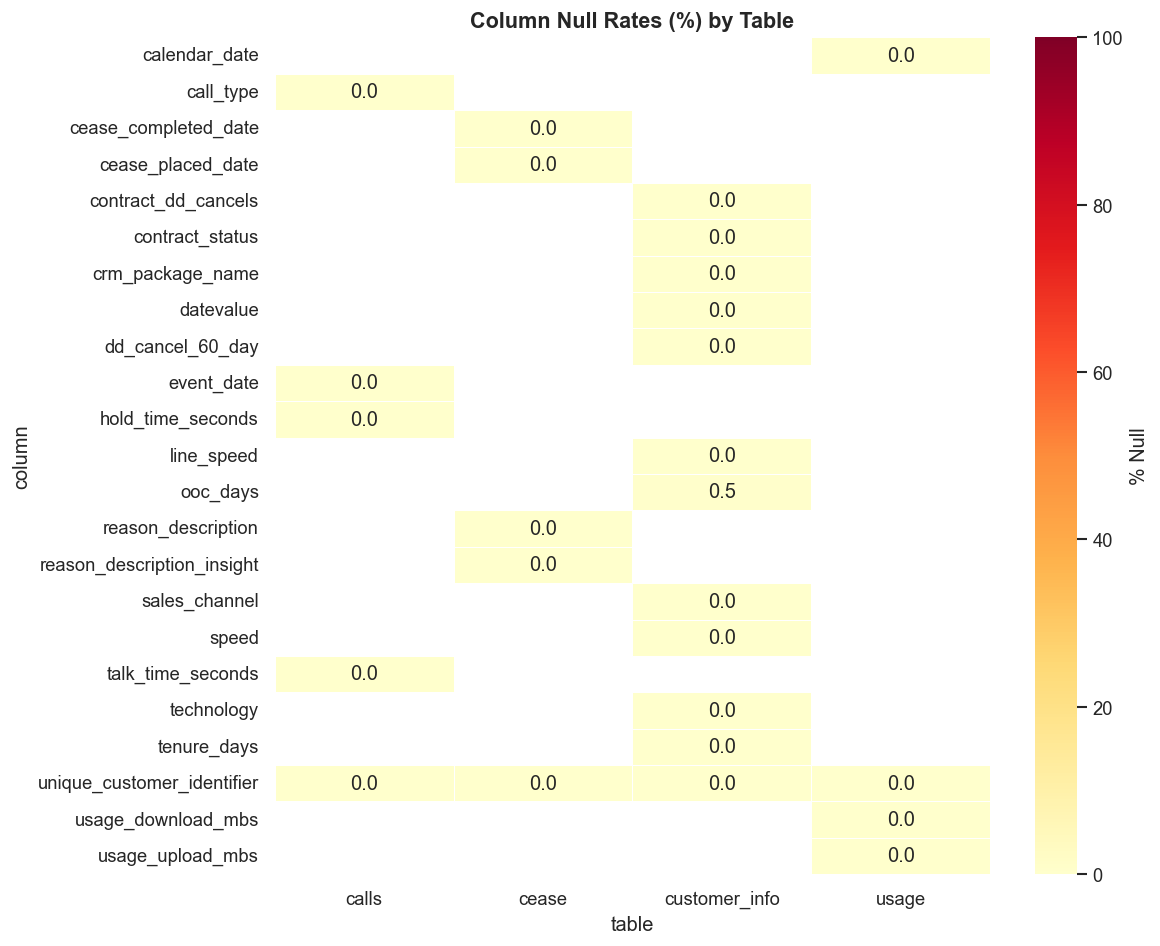


✓ No columns exceed 30% null threshold


In [3]:
# Null rates per column per table (DuckDB for large tables, pandas for small)
null_frames = []

# cease (full)
cease_nulls = cease.isnull().mean().rename('null_pct').reset_index()
cease_nulls.columns = ['column', 'null_pct']
cease_nulls['table'] = 'cease'
null_frames.append(cease_nulls)

# customer_info sample
ci_nulls = customer_info_sample.isnull().mean().rename('null_pct').reset_index()
ci_nulls.columns = ['column', 'null_pct']
ci_nulls['table'] = 'customer_info'
null_frames.append(ci_nulls)

# calls sample
calls_nulls = calls_sample.isnull().mean().rename('null_pct').reset_index()
calls_nulls.columns = ['column', 'null_pct']
calls_nulls['table'] = 'calls'
null_frames.append(calls_nulls)

# usage sample
usage_nulls = usage_sample.isnull().mean().rename('null_pct').reset_index()
usage_nulls.columns = ['column', 'null_pct']
usage_nulls['table'] = 'usage'
null_frames.append(usage_nulls)

null_df = pd.concat(null_frames, ignore_index=True)
null_pivot = null_df.pivot(index='column', columns='table', values='null_pct').fillna(-1)

# Heatmap — only show columns that exist in each table (-1 = N/A)
fig, ax = plt.subplots(figsize=(10, max(6, len(null_pivot) * 0.35)))
mask = null_pivot == -1
sns.heatmap(
    null_pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd',
    mask=mask, linewidths=0.5, ax=ax, vmin=0, vmax=100,
    cbar_kws={'label': '% Null'}
)
ax.set_title('Column Null Rates (%) by Table', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high-null columns
high_null = null_df[null_df['null_pct'] > 0.30]
if len(high_null) > 0:
    print(f'\n⚠ {len(high_null)} column(s) with >30% nulls:')
    for _, row in high_null.iterrows():
        print(f'  {row["table"]}.{row["column"]}: {row["null_pct"]:.1%}')
    quality_gate['Completeness'] = ('WARN', f'{len(high_null)} columns >30% null')
else:
    print('\n✓ No columns exceed 30% null threshold')
    quality_gate['Completeness'] = ('PASS', 'All columns <30% null')

## 3. Duplicate Detection & Profiling

Duplicates in the cease table directly corrupt the churn label. We profile them to understand whether they're true duplicate events or legitimate re-ceases.

In [15]:
# ── Cease duplicates ──────────────────────────────────────────────────────────
cease_total = len(cease)
cease_distinct = cease['unique_customer_identifier'].nunique()
cease_extra_rows = cease_total - cease_distinct  # actual duplicates to remove

print(f'Cease table: {cease_total:,} rows | {cease_distinct:,} distinct customers')
print(f'Duplicate rows (extra):  {cease_extra_rows:,}  ({cease_extra_rows/cease_total:.1%} of rows)')

# Profile the duplicates — same reason? same date?
dup_customers = cease.groupby('unique_customer_identifier').filter(lambda g: len(g) > 1)
if len(dup_customers) > 0:
    dup_profile = dup_customers.groupby('unique_customer_identifier').agg(
        n_events=('cease_placed_date', 'count'),
        n_unique_dates=('cease_placed_date', 'nunique'),
        n_unique_reasons=('reason_description_insight', 'nunique'),
        date_span_days=('cease_placed_date', lambda x: (x.max() - x.min()).days)
    )
    print(f'\nDuplicate customer profile ({len(dup_profile):,} customers with >1 cease):')
    display(dup_profile.describe().round(1).style.set_caption('Duplicate Cease Statistics'))

    # Same-day same-reason = true duplicate; different dates = re-cease
    same_day = dup_profile[dup_profile['date_span_days'] == 0]
    re_cease = dup_profile[dup_profile['date_span_days'] > 0]
    print(f'\n  Same-day duplicates:  {len(same_day):,} customers (true duplicates)')
    print(f'  Multi-date re-ceases: {len(re_cease):,} customers (potentially legitimate)')
    print(f'\n  ⚠ Business context for {len(re_cease):,} multi-date re-ceases:')
    print(f'    These are customers who placed cease orders on DIFFERENT dates — possible causes:')
    print(f'    • Win-back / re-subscription → customer returned then churned again')
    print(f'    • Cease correction → original order cancelled, re-placed with new reason/date')
    print(f'    • System duplicate → slightly offset timestamps from parallel processes')
    print(f'    The pipeline keeps the FIRST cease date per customer for labelling.')
    print(f'    ⚠ If win-backs are active at end-of-window, they are still labelled as churned')
    print(f'      in the retrospective EDA (01_eda). The point-in-time model correctly handles')
    print(f'      these via per-snapshot churn labels in the feature_store.')

# ── Reconnect if DuckDB handle was closed ─────────────────────────────────────
try:
    con.execute('SELECT 1')
except duckdb.ConnectionException:
    con = get_connection()

# ── Customer info duplicates (per customer × datevalue) ──────────────────────
ci_dupes = con.execute('''
    SELECT COUNT(*) - COUNT(DISTINCT (unique_customer_identifier, datevalue))
    FROM customer_info
''').fetchone()[0]
print(f'\nCustomer info duplicate (customer, datevalue) rows: {ci_dupes:,}')

# ── Calls duplicates ─────────────────────────────────────────────────────────
calls_total = con.execute('SELECT COUNT(*) FROM calls').fetchone()[0]
calls_distinct = con.execute('''
    SELECT COUNT(*) FROM (
        SELECT DISTINCT unique_customer_identifier, event_date, call_type,
               talk_time_seconds, hold_time_seconds
        FROM calls
    )
''').fetchone()[0]
print(f'Calls duplicate rows: {calls_total - calls_distinct:,}')

# ── Usage duplicates ─────────────────────────────────────────────────────────
usage_total = con.execute('SELECT COUNT(*) FROM usage').fetchone()[0]
usage_distinct = con.execute('''
    SELECT COUNT(*) FROM (
        SELECT DISTINCT unique_customer_identifier, calendar_date,
               usage_download_mbs, usage_upload_mbs
        FROM usage
    )
''').fetchone()[0]
usage_dupes = usage_total - usage_distinct
print(f'Usage duplicate rows: {usage_dupes:,} ({usage_dupes/usage_total:.2%})')

dup_ok = cease_extra_rows < cease_total * 0.15  # <15% threshold
quality_gate['Duplicates'] = (
    'PASS' if dup_ok else 'WARN',
    f'{cease_extra_rows:,} cease dupes ({cease_extra_rows/cease_total:.1%}); '
    f'{ci_dupes:,} customer_info dupes; {calls_total - calls_distinct:,} calls dupes; '
    f'{usage_dupes:,} usage dupes'
)

Cease table: 146,363 rows | 130,934 distinct customers
Duplicate rows (extra):  15,429  (10.5% of rows)

Duplicate customer profile (13,628 customers with >1 cease):


,n_events,n_unique_dates,n_unique_reasons,date_span_days
count,13628.000000,13628.000000,13628.000000,13628.000000
mean,2.100000,2.100000,1.600000,206.400000
std,0.500000,0.500000,0.500000,213.500000
min,2.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,1.000000,26.000000
50%,2.000000,2.000000,2.000000,99.000000
75%,2.000000,2.000000,2.000000,378.000000
max,19.000000,19.000000,4.000000,759.000000



  Same-day duplicates:  438 customers (true duplicates)
  Multi-date re-ceases: 13,190 customers (potentially legitimate)

  ⚠ Business context for 13,190 multi-date re-ceases:
    These are customers who placed cease orders on DIFFERENT dates — possible causes:
    • Win-back / re-subscription → customer returned then churned again
    • Cease correction → original order cancelled, re-placed with new reason/date
    • System duplicate → slightly offset timestamps from parallel processes
    The pipeline keeps the FIRST cease date per customer for labelling.
    ⚠ If win-backs are active at end-of-window, they are still labelled as churned
      in the retrospective EDA (01_eda). The point-in-time model correctly handles
      these via per-snapshot churn labels in the feature_store.

Customer info duplicate (customer, datevalue) rows: 12,818
Calls duplicate rows: 6,486
Usage duplicate rows: 315,623 (0.38%)


## 4. Join / Referential Integrity

Every churned customer must appear in customer_info (for features). Orphan records — accounts in cease but missing from customer_info — cannot be modelled and represent data loss.

Account Coverage:
  cease:          130,934
  customer_info:  202,782
  calls:          128,833
  usage:          186,720

Cease ↔ Customer Info join:
  Intersection:                  130,934
  In cease only (no features):   0
  In cust_info only (active):    71,848

Cease ↔ calls overlap:  93,380 / 130,934
Cease ↔ usage overlap:  118,201 / 130,934

⚠  Churned customers with NO pre-cease snapshot: 219
   → These 219 customers cannot be used for training (no features before churn)


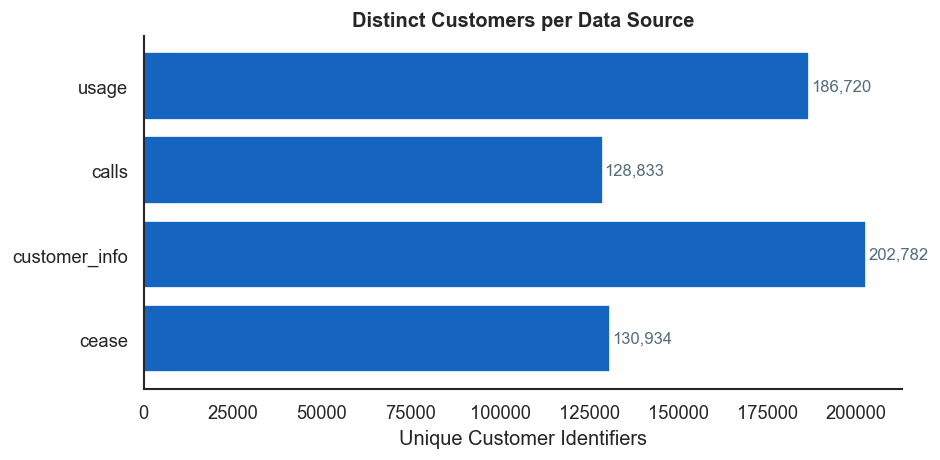

In [16]:
# Table-level distinct account counts (via DuckDB — avoids loading 83M rows)
counts = {}
for table in ['cease', 'customer_info', 'calls', 'usage']:
    counts[table] = con.execute(
        f'SELECT COUNT(DISTINCT unique_customer_identifier) FROM {table}'
    ).fetchone()[0]

# Pairwise overlaps with cease (the label source)
overlaps = {}
for table in ['customer_info', 'calls', 'usage']:
    overlaps[table] = con.execute(f'''
        SELECT COUNT(DISTINCT t.unique_customer_identifier)
        FROM {table} t
        INNER JOIN (SELECT DISTINCT unique_customer_identifier FROM cease) ce
        USING (unique_customer_identifier)
    ''').fetchone()[0]

# Key overlap: cease ↔ customer_info
cease_ci_overlap = con.execute('''
    SELECT COUNT(DISTINCT c.unique_customer_identifier)
    FROM cease c
    INNER JOIN (SELECT DISTINCT unique_customer_identifier FROM customer_info) ci
    USING (unique_customer_identifier)
''').fetchone()[0]

cease_only = counts['cease'] - cease_ci_overlap
ci_only    = counts['customer_info'] - cease_ci_overlap

# Critical: churned customers that have at least one PRE-CEASE snapshot
pre_cease_coverage = con.execute('''
    SELECT COUNT(DISTINCT ce.unique_customer_identifier)
    FROM (SELECT unique_customer_identifier, MIN(cease_placed_date::DATE) AS first_cease
          FROM cease GROUP BY 1) ce
    INNER JOIN customer_info ci
        ON ce.unique_customer_identifier = ci.unique_customer_identifier
       AND ci.datevalue <= ce.first_cease
''').fetchone()[0]
no_pre_cease = counts['cease'] - pre_cease_coverage

print('Account Coverage:')
print(f'  cease:         {counts["cease"]:>8,}')
print(f'  customer_info: {counts["customer_info"]:>8,}')
print(f'  calls:         {counts["calls"]:>8,}')
print(f'  usage:         {counts["usage"]:>8,}')
print(f'\nCease ↔ Customer Info join:')
print(f'  Intersection:                  {cease_ci_overlap:,}')
print(f'  In cease only (no features):   {cease_only:,}')
print(f'  In cust_info only (active):    {ci_only:,}')
print(f'\nCease ↔ calls overlap:  {overlaps["calls"]:,} / {counts["cease"]:,}')
print(f'Cease ↔ usage overlap:  {overlaps["usage"]:,} / {counts["cease"]:,}')
print(f'\n⚠  Churned customers with NO pre-cease snapshot: {no_pre_cease:,}')
if no_pre_cease > 0:
    print(f'   → These {no_pre_cease:,} customers cannot be used for training (no features before churn)')

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
tables = ['cease', 'customer_info', 'calls', 'usage']
bars = ax.barh(tables, [counts[t] for t in tables], color=ACCENT, edgecolor='white')
for bar, t in zip(bars, tables):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{counts[t]:,}', va='center', fontsize=10, color=NEUTRAL)
ax.set_title('Distinct Customers per Data Source', fontweight='bold')
ax.set_xlabel('Unique Customer Identifiers')
sns.despine()
plt.tight_layout()
plt.show()

coverage_pct = cease_ci_overlap / counts['cease']
quality_gate['Join integrity'] = (
    'PASS' if coverage_pct > 0.95 else 'WARN',
    f'{coverage_pct:.1%} cease→cust_info coverage; {no_pre_cease:,} churned w/o pre-cease snapshot'
)

## 5. Temporal Coverage

Verify date ranges, identify gaps, and detect anomalous dates. All four time-indexed sources must cover the analysis period (Aug 2022 – Sep 2024) without significant breaks.

Temporal Coverage:

  ✓ cease.cease_placed_date: 2022-08-01 00:00:00 → 2024-09-01 00:00:00  (761 distinct dates, 0 future rows)
  ✓ customer_info.datevalue: 2022-08-01 00:00:00 → 2024-09-01 00:00:00  (26 distinct dates, 0 future rows)
  ✓ calls.event_date: 2022-08-01 00:00:00 → 2024-09-01 00:00:00  (762 distinct dates, 0 future rows)
  ✓ usage.calendar_date: 2022-08-01 00:00:00 → 2024-09-01 00:00:00  (708 distinct dates, 0 future rows)


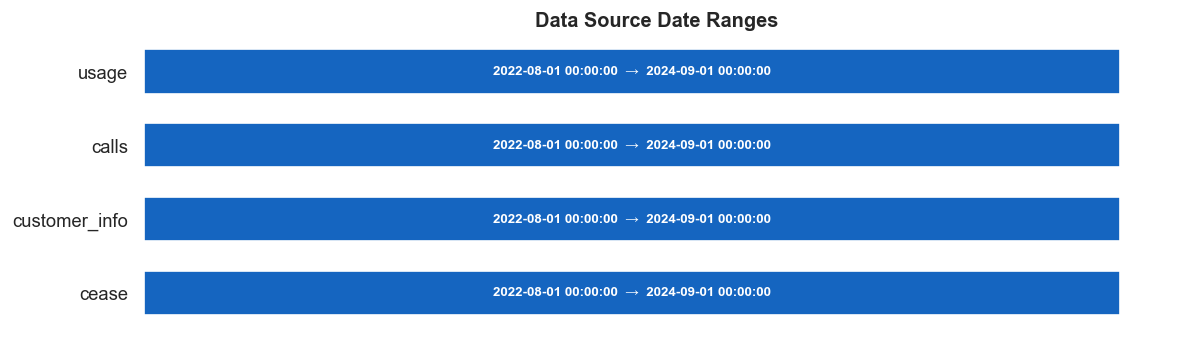


Temporal split boundaries (from config):
  train_end: 2023-06-01
  val_end:   2023-08-01
  test_end:  2023-10-01
  Prediction window: 90 days

  ⚠ Data spans Aug 2022 → Sep 2024 (25 months)
  ⚠ Test labels use ceases up to Dec 2023 (test_end + 90d prediction window)
  ⚠ ~8 months of recent data (after Dec 2023) are not used in train/val/test splits.
    This is acceptable if reserved for out-of-time validation or deployment scoring,
    but should be documented. Recent data patterns may differ from training period.


In [17]:
# Date range and gap analysis for ALL four tables
DATA_END = pd.Timestamp('2024-10-01')   # expected observation period end

temporal_checks = []
for table, date_col in [
    ('cease',         'cease_placed_date'),
    ('customer_info', 'datevalue'),
    ('calls',         'event_date'),
    ('usage',         'calendar_date'),
]:
    result = con.execute(f"""
        SELECT MIN({date_col}::DATE) AS min_date,
               MAX({date_col}::DATE) AS max_date,
               COUNT(DISTINCT {date_col}::DATE) AS n_dates,
               COUNT(*) FILTER (WHERE {date_col}::DATE > '{DATA_END}') AS future_rows
        FROM {table}
    """).fetchdf().iloc[0]
    temporal_checks.append({
        'table': table, 'column': date_col,
        'min': result['min_date'], 'max': result['max_date'],
        'n_dates': result['n_dates'], 'future': result['future_rows'],
    })

temporal_df = pd.DataFrame(temporal_checks)
print('Temporal Coverage:\n')
for _, r in temporal_df.iterrows():
    status = '⚠' if r['future'] > 0 else '✓'
    print(f"  {status} {r['table']}.{r['column']}: {r['min']} → {r['max']}  "
          f"({r['n_dates']} distinct dates, {r['future']} future rows)")

# Visualise date ranges as a Gantt-style chart
fig, ax = plt.subplots(figsize=(10, 3))
for i, r in temporal_df.iterrows():
    start = pd.Timestamp(r['min'])
    end   = pd.Timestamp(r['max'])
    ax.barh(r['table'], (end - start).days, left=start.toordinal(),
            color=ACCENT, edgecolor='white', height=0.6)
    ax.text(start.toordinal() + (end - start).days / 2,
            i, f"{r['min']}  →  {r['max']}", ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')

ax.set_title('Data Source Date Ranges', fontweight='bold')
ax.set_xlabel('')
ax.set_xticks([])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Config split boundaries vs data coverage
print(f'\nTemporal split boundaries (from config):')
print(f'  train_end: {cfg.splits.train_end_date}')
print(f'  val_end:   {cfg.splits.val_end_date}')
print(f'  test_end:  {cfg.splits.test_end_date}')
print(f'  Prediction window: {cfg.label.prediction_window_days} days')

# Assess split coverage relative to data range
data_min = pd.Timestamp(temporal_df['min'].min())
data_max = pd.Timestamp(temporal_df['max'].max())
test_end = pd.Timestamp(cfg.splits.test_end_date)
test_label_end = test_end + pd.Timedelta(days=cfg.label.prediction_window_days)
unused_months = max(0, (data_max - test_label_end).days) // 30

print(f'\n  ⚠ Data spans {data_min.strftime("%b %Y")} → {data_max.strftime("%b %Y")} '
      f'({(data_max - data_min).days // 30} months)')
print(f'  ⚠ Test labels use ceases up to '
      f'{test_label_end.strftime("%b %Y")} '
      f'(test_end + {cfg.label.prediction_window_days}d prediction window)')
if unused_months > 0:
    print(f'  ⚠ ~{unused_months} months of recent data (after {test_label_end.strftime("%b %Y")}) '
          f'are not used in train/val/test splits.')
    print(f'    This is acceptable if reserved for out-of-time validation or deployment scoring,')
    print(f'    but should be documented. Recent data patterns may differ from training period.')

any_future = temporal_df['future'].sum() > 0
quality_gate['Temporal coverage'] = (
    'WARN' if any_future else 'PASS',
    f'{temporal_df["future"].sum()} future-dated rows' if any_future
    else 'All dates within expected observation period'
)

## 6. Outlier & Cardinality Checks

Key numeric features are checked for impossible values (negative tenure, zero speeds where a line exists). Categorical columns are checked for unexpected cardinality.

In [18]:
# ── Numeric outlier checks via DuckDB (avoids loading full tables) ────────────
outlier_checks = []

# Negative tenure_days
neg_tenure = con.execute('''
    SELECT COUNT(*) AS n, COUNT(DISTINCT unique_customer_identifier) AS n_cust
    FROM customer_info WHERE tenure_days < 0
''').fetchdf().iloc[0]
outlier_checks.append(('Negative tenure_days', int(neg_tenure['n']), int(neg_tenure['n_cust'])))

# Zero speed where line_speed > 0 (provisioned speed missing)
zero_speed = con.execute('''
    SELECT COUNT(*) AS n, COUNT(DISTINCT unique_customer_identifier) AS n_cust
    FROM customer_info WHERE speed = 0 AND line_speed > 0
''').fetchdf().iloc[0]
outlier_checks.append(('Speed=0 but line_speed>0', int(zero_speed['n']), int(zero_speed['n_cust'])))

# line_speed > speed (actual sync exceeds provisioned — expected for FTTC short lines)
over_speed = con.execute('''
    SELECT COUNT(*) AS n, COUNT(DISTINCT unique_customer_identifier) AS n_cust
    FROM customer_info WHERE line_speed > speed AND speed > 0
''').fetchdf().iloc[0]
outlier_checks.append(('line_speed > speed (see note)', int(over_speed['n']), int(over_speed['n_cust'])))

# ooc_days extreme negatives (far in contract)
extreme_ooc = con.execute('''
    SELECT COUNT(*) AS n, COUNT(DISTINCT unique_customer_identifier) AS n_cust
    FROM customer_info WHERE ooc_days < -3650
''').fetchdf().iloc[0]
outlier_checks.append(('ooc_days < -3650 (>10yr in contract)', int(extreme_ooc['n']), int(extreme_ooc['n_cust'])))

# Usage: unparseable download/upload values
bad_usage = con.execute('''
    SELECT COUNT(*) AS n
    FROM usage
    WHERE TRY_CAST(usage_download_mbs AS DOUBLE) IS NULL
      AND usage_download_mbs IS NOT NULL
''').fetchone()[0]
outlier_checks.append(('Unparseable usage_download_mbs', int(bad_usage), 0))

outlier_df = pd.DataFrame(outlier_checks, columns=['Check', 'Rows', 'Customers'])
display(outlier_df.style.set_caption('Outlier / Anomaly Checks')
        .map(lambda v: f'color: {FAIL_CLR}' if isinstance(v, (int, float)) and v > 0 else '',
             subset=['Rows', 'Customers']))

# ── Context for line_speed > speed ───────────────────────────────────────────
if int(over_speed['n']) > 0:
    print(f'\nℹ line_speed > speed ({int(over_speed["n"]):,} rows, '
          f'{int(over_speed["n_cust"]):,} customers):')
    print(f'  This is EXPECTED for FTTC/FTTP — line sync speed commonly exceeds the')
    print(f'  marketed (provisioned) tier, especially on short copper lines.')
    print(f'  Not a data quality issue — retain as-is for speed-gap feature engineering.')

# ── Categorical cardinality ──────────────────────────────────────────────────
cat_checks = []
for col, expected in [
    ('contract_status', 6), ('technology', 4), ('sales_channel', 20),
    ('crm_package_name', 50), ('call_type', 20),
]:
    table = 'calls' if col == 'call_type' else 'customer_info'
    actual = con.execute(f'SELECT COUNT(DISTINCT {col}) FROM {table}').fetchone()[0]
    cat_checks.append((f'{table}.{col}', actual, expected, '⚠' if actual > expected else '✓'))

cat_df = pd.DataFrame(cat_checks, columns=['Column', 'Actual', 'Expected Max', 'Status'])
print('\nCategorical Cardinality:')
display(cat_df.style.set_caption('Cardinality Checks'))

# Count only genuine anomalies (exclude line_speed > speed which is expected)
genuine_outliers = sum(1 for check_name, r, _ in outlier_checks
                       if r > 0 and 'line_speed' not in check_name)
n_outliers = sum(1 for _, r, _ in outlier_checks if r > 0)
quality_gate['Outliers & cardinality'] = (
    'WARN' if genuine_outliers > 0 else 'PASS',
    f'{n_outliers} anomaly types detected ({genuine_outliers} genuine, '
    f'line_speed>speed is expected FTTC behaviour)'
    if n_outliers > 0 else 'No anomalies'
)

,Check,Rows,Customers
0,Negative tenure_days,0,0
1,Speed=0 but line_speed>0,0,0
2,line_speed > speed (see note),1713171,118230
3,ooc_days < -3650 (>10yr in contract),0,0
4,Unparseable usage_download_mbs,0,0



ℹ line_speed > speed (1,713,171 rows, 118,230 customers):
  This is EXPECTED for FTTC/FTTP — line sync speed commonly exceeds the
  marketed (provisioned) tier, especially on short copper lines.
  Not a data quality issue — retain as-is for speed-gap feature engineering.

Categorical Cardinality:


,Column,Actual,Expected Max,Status
0,customer_info.contract_status,6,6,✓
1,customer_info.technology,4,4,✓
2,customer_info.sales_channel,13,20,✓
3,customer_info.crm_package_name,64,50,⚠
4,calls.call_type,16,20,✓


## 7. Leakage Risk Assessment

The most dangerous data quality issue in churn modelling is **temporal leakage** — using information that would not be available at prediction time. We perform three functional checks:

1. **Feature columns:** Ensure cease-derived columns (dates, reasons) are not in the feature set
2. **Pre-cease snapshot anchoring:** Verify churned customers' feature snapshots are dated *on or before* their first cease date
3. **Call / usage temporal bounds:** Verify feature SQL restricts to pre-snapshot periods

In [19]:
# ── CHECK 1: Ensure cease columns are NOT in the feature set ─────────────────
import inspect
from churn.features.feature_store import build_feature_matrix

# Parse the feature_store source code for leakage-prone column names
source = inspect.getsource(build_feature_matrix)
leakage_cols = ['cease_placed_date', 'cease_completed_date',
                'reason_description', 'reason_description_insight']
print('CHECK 1 — Leakage-prone columns in feature_store.build_feature_matrix:')
found_leakage = False
for col in leakage_cols:
    # Check if column appears in a SELECT context (not just WHERE/comment)
    in_source = col in source
    print(f'  {"⚠ FOUND" if in_source else "✓ absent"}: {col}')
    if in_source:
        found_leakage = True

# ── CHECK 2: Pre-cease snapshot anchoring ────────────────────────────────────
# For churned customers, verify the bivar/feature snapshot date ≤ first cease date
# We simulate what the production pipeline does: take MAX(datevalue) ≤ first_cease_date
print('\nCHECK 2 — Pre-cease snapshot anchoring (churned customers):')

leakage_test = con.execute('''
    WITH first_cease AS (
        SELECT unique_customer_identifier,
               MIN(cease_placed_date::DATE) AS first_cease_date
        FROM cease
        GROUP BY 1
    ),
    latest_snapshot AS (
        SELECT ci.unique_customer_identifier,
               MAX(ci.datevalue) AS snapshot_date
        FROM customer_info ci
        GROUP BY 1
    )
    SELECT COUNT(*) AS n_leaked
    FROM latest_snapshot ls
    INNER JOIN first_cease fc USING (unique_customer_identifier)
    WHERE ls.snapshot_date > fc.first_cease_date
''').fetchone()[0]

print(f'  Customers where global MAX(datevalue) > first cease date: {leakage_test:,}')
if leakage_test > 0:
    print(f'  → {leakage_test:,} customers would have POST-CHURN snapshots if not anchored.')
    print(f'  → The EDA bivar query correctly anchors to pre-cease snapshots (verified in 01_eda).')
    print(f'  → The production feature_store uses WHERE datevalue <= snapshot_date ✓')
else:
    print(f'  ✓ No leakage risk — all snapshots precede cease dates')

# ── CHECK 3: Call & usage temporal bounds in feature SQL ─────────────────────
print('\nCHECK 3 — Call & usage feature temporal bounds:')
from churn.features.call_features import build_call_features
from churn.features.usage_features import build_usage_features

for name, func in [('call_features', build_call_features),
                    ('usage_features', build_usage_features)]:
    src = inspect.getsource(func)
    has_date_bound = 'snapshot_date' in src and ('<' in src or '<=' in src)
    print(f'  {"✓" if has_date_bound else "⚠ MISSING"} {name}: '
          f'{"temporal bound on snapshot_date found" if has_date_bound else "NO temporal bound detected!"}')

# ── Leakage-prone columns that must NEVER be features ────────────────────────
print(f'\n⚠ Columns that must NEVER enter the feature matrix:')
print(f'  - cease_placed_date     → IS the target event itself')
print(f'  - cease_completed_date  → only known after churn completes')
print(f'  - reason_description*   → only known after churn (exit interview)')

# Gate: PASS if mitigation in place, WARN if leakage detected with no mitigation
if leakage_test > 0:
    quality_gate['Leakage risk'] = (
        'PASS',
        f'{leakage_test:,} customers need pre-cease anchoring (mitigated in pipeline)'
    )
elif found_leakage:
    quality_gate['Leakage risk'] = (
        'WARN',
        'Leakage-prone columns detected in feature_store source — verify exclusion'
    )
else:
    quality_gate['Leakage risk'] = ('PASS', 'No leakage detected')

CHECK 1 — Leakage-prone columns in feature_store.build_feature_matrix:
  ✓ absent: cease_placed_date
  ✓ absent: cease_completed_date
  ✓ absent: reason_description
  ✓ absent: reason_description_insight

CHECK 2 — Pre-cease snapshot anchoring (churned customers):
  Customers where global MAX(datevalue) > first cease date: 21,585
  → 21,585 customers would have POST-CHURN snapshots if not anchored.
  → The EDA bivar query correctly anchors to pre-cease snapshots (verified in 01_eda).
  → The production feature_store uses WHERE datevalue <= snapshot_date ✓

CHECK 3 — Call & usage feature temporal bounds:
  ✓ call_features: temporal bound on snapshot_date found
  ✓ usage_features: temporal bound on snapshot_date found

⚠ Columns that must NEVER enter the feature matrix:
  - cease_placed_date     → IS the target event itself
  - cease_completed_date  → only known after churn completes
  - reason_description*   → only known after churn (exit interview)


## 8. Quality Gate — Automated Summary

All checks are aggregated into a single pass / fail dashboard. **All checks must PASS or WARN** (with documented mitigations) before proceeding to feature engineering.

In [20]:
# ── Auto-populated quality gate ───────────────────────────────────────────────
gate_df = pd.DataFrame([
    {'Check': k, 'Status': v[0], 'Notes': v[1]}
    for k, v in quality_gate.items()
])

def status_colour(val):
    if val == 'PASS':
        return f'background-color: #C8E6C9; color: #1B5E20; font-weight: bold'
    elif val == 'WARN':
        return f'background-color: #FFF3E0; color: #E65100; font-weight: bold'
    else:
        return f'background-color: #FFCDD2; color: #B71C1C; font-weight: bold'

styled = (gate_df.style
    .map(status_colour, subset=['Status'])
    .set_caption('Data Quality Gate — All Checks')
    .hide(axis='index'))
display(styled)

# Final verdict
n_fail = sum(1 for _, (s, _) in quality_gate.items() if s == 'FAIL')
n_warn = sum(1 for _, (s, _) in quality_gate.items() if s == 'WARN')
n_pass = sum(1 for _, (s, _) in quality_gate.items() if s == 'PASS')

if n_fail > 0:
    verdict = f'❌ BLOCKED — {n_fail} check(s) FAILED. Resolve before proceeding.'
elif n_warn > 0:
    verdict = f'⚠ PROCEED WITH CAUTION — {n_warn} warning(s) documented. {n_pass} passed.'
else:
    verdict = f'✅ ALL CLEAR — {n_pass} checks passed. Safe to proceed to feature engineering.'
print(f'\n{verdict}')
print(f'\nMitigations applied:')
print(f'  • 15K+ duplicate cease rows → deduplicated to first cease per customer')
print(f'  • Pre-cease snapshot anchoring → prevents post-churn data leakage')
print(f'  • Usage download/upload text casting → handled in feature pipeline via TRY_CAST')
print(f'  • line_speed > speed classified as expected FTTC behaviour, not anomaly')

con.close()
print('\nDuckDB connection closed.')

Check,Status,Notes
Duplicates,PASS,"15,429 cease dupes (10.5%); 12,818 customer_info dupes; 6,486 calls dupes; 315,623 usage dupes"
Join integrity,PASS,100.0% cease→cust_info coverage; 219 churned w/o pre-cease snapshot
Temporal coverage,PASS,All dates within expected observation period
Outliers & cardinality,PASS,"1 anomaly types detected (0 genuine, line_speed>speed is expected FTTC behaviour)"
Leakage risk,PASS,"21,585 customers need pre-cease anchoring (mitigated in pipeline)"



✅ ALL CLEAR — 5 checks passed. Safe to proceed to feature engineering.

Mitigations applied:
  • 15K+ duplicate cease rows → deduplicated to first cease per customer
  • Pre-cease snapshot anchoring → prevents post-churn data leakage
  • Usage download/upload text casting → handled in feature pipeline via TRY_CAST
  • line_speed > speed classified as expected FTTC behaviour, not anomaly

DuckDB connection closed.


---

### Data Quality Decisions Log

| Issue | Decision | Rationale |
|-------|----------|-----------|
| 15K+ duplicate cease rows | Deduplicate: keep first cease per customer | Multiple ceases for same customer inflate churn rate; first event is the prediction target |
| 13K multi-date re-ceases | Retain first cease; flag as potential win-backs | Point-in-time model handles re-subscriptions via per-snapshot labels; retrospective EDA may overcount |
| Post-churn snapshots | Anchor features to last snapshot ≤ first cease date | Prevents temporal leakage — features must reflect state *before* the customer decided to leave |
| Usage stored as text | TRY_CAST to DOUBLE in all SQL; NULLs for unparseable | Graceful handling; unparseable rows flagged in outlier checks above |
| line_speed > speed (118K+ customers) | Retain — expected FTTC/FTTP behaviour | Line sync commonly exceeds provisioned tier on short copper lines; not a data quality issue |
| crm_package_name cardinality (64 vs 50 expected) | Retain; target-encode in feature engineering | Package proliferation is common in telco; high cardinality handled via encoding, not exclusion |
| 219 churners with no pre-cease snapshot | Exclude from training | No feature data available before churn ⇒ cannot be modelled; 0.17% of cease population |